# Part 2 — Bias Audit 

This notebook audits bias in the toxicity classifier using the Jigsaw unintended bias dataset on CPU without using `Trainer` or `TrainingArguments`.


In [3]:
!pip install -U transformers datasets scikit-learn pandas matplotlib seaborn aif360



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [5]:
DATA_PATH = r"C:\Users\maaaa\Desktop\RAI_assignment2\jigsaw-unintended-bias-train.csv"
MODEL_DIR = "./models_cpu_part1"
FAST_MODE = True

if FAST_MODE:
    EVAL_SIZE = 5000
    MAX_LENGTH = 96
    BATCH_SIZE = 16
else:
    EVAL_SIZE = 20000
    MAX_LENGTH = 128
    BATCH_SIZE = 16

THRESHOLD = 0.5

print({
    "DATA_PATH": DATA_PATH,
    "MODEL_DIR": MODEL_DIR,
    "FAST_MODE": FAST_MODE,
    "EVAL_SIZE": EVAL_SIZE,
    "MAX_LENGTH": MAX_LENGTH,
    "BATCH_SIZE": BATCH_SIZE,
    "THRESHOLD": THRESHOLD
})


{'DATA_PATH': 'C:\\Users\\maaaa\\Desktop\\RAI_assignment2\\jigsaw-unintended-bias-train.csv', 'MODEL_DIR': './models_cpu_part1', 'FAST_MODE': True, 'EVAL_SIZE': 5000, 'MAX_LENGTH': 96, 'BATCH_SIZE': 16, 'THRESHOLD': 0.5}


In [6]:
import pandas as pd

needed_cols = ["comment_text", "toxic", "black", "white"]

chunks = []
target_rows = 60000   # enough for CPU work
taken = 0

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=needed_cols,
    dtype={
        "toxic": "float32",
        "black": "float32",
        "white": "float32",
    },
    chunksize=20000
):
    chunk = chunk.dropna(subset=["comment_text", "toxic", "black", "white"]).copy()
    chunks.append(chunk)
    taken += len(chunk)
    if taken >= target_rows:
        break

df = pd.concat(chunks, ignore_index=True)
df["label"] = (df["toxic"] >= 0.5).astype("int8")

print("Loaded rows:", len(df))
df.head()

Loaded rows: 60241


,comment_text,toxic,black,white,label
0,haha you guys are a bunch of losers.,0.893617,0.0,0.0,1
1,This is a great story. Man. I wonder if the pe...,0.440000,0.0,0.0,0
2,"Angry trolls, misogynists and Racists"", oh my....",0.500000,0.0,0.0,1
3,Nice to some attempts to try to make comments ...,0.000000,0.0,0.0,0
4,Yet call out all Muslims for the acts of a few...,0.912500,0.0,0.0,1


In [7]:
_, eval_df = train_test_split(
    df,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=SEED
)

eval_df = eval_df.reset_index(drop=True)
print("Evaluation subset size:", len(eval_df))
print(eval_df["label"].value_counts(normalize=True))


Evaluation subset size: 5000
label
0    0.886
1    0.114
Name: proportion, dtype: float64


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()
device = torch.device("cpu")
model.to(device)

print("Model loaded from:", MODEL_DIR)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8014.54it/s]

Model loaded from: ./models_cpu_part1


In [9]:
def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

eval_dataset = Dataset.from_pandas(eval_df[["comment_text"]].copy())
eval_dataset = eval_dataset.map(tokenize_function, batched=True)
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator)

all_probs = []

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

eval_df["score"] = np.array(all_probs)
eval_df["pred"] = (eval_df["score"] >= THRESHOLD).astype(int)

eval_df[["comment_text", "label", "score", "pred", "black", "white"]].head()


Map: 100%|██████████| 5000/5000 [00:00<00:00, 6550.03 examples/s]


,comment_text,label,score,pred,black,white
0,"""Fahrenheit 451"" is a seditious book. It shou...",0,0.003481,0,0.0,0.0
1,"Please, if you would, tell me how I make law e...",0,0.001673,0,0.0,0.0
2,Heartbreaking.......,0,0.001080,0,0.0,0.0
3,I have never heard about someone overdosing on...,0,0.001289,0,0.0,0.0
4,"Part of the problem is your use of the word ""t...",0,0.000880,0,0.0,0.0


In [10]:
high_black = eval_df[eval_df["black"] >= 0.5].copy()
reference = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print("High-black cohort size:", len(high_black))
print("Reference cohort size:", len(reference))


High-black cohort size: 222
Reference cohort size: 192


In [11]:
def safe_div(a, b):
    return a / b if b != 0 else np.nan

def cohort_metrics(df_cohort):
    y_true = df_cohort["label"].values
    y_pred = df_cohort["pred"].values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = safe_div(tp, tp + fn)
    fpr = safe_div(fp, fp + tn)
    fnr = safe_div(fn, fn + tp)
    precision = safe_div(tp, tp + fp)
    positive_rate = np.mean(y_pred)

    return {
        "size": len(df_cohort),
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TPR": tpr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "PositivePredictionRate": positive_rate
    }

hb_metrics = cohort_metrics(high_black)
ref_metrics = cohort_metrics(reference)

metrics_table = pd.DataFrame([hb_metrics, ref_metrics], index=["high_black", "reference"])
metrics_table


,size,TP,TN,FP,FN,TPR,FPR,FNR,Precision,PositivePredictionRate
high_black,222,20,151,12,39,0.338983,0.073620,0.661017,0.625000,0.144144
reference,192,14,138,13,27,0.341463,0.086093,0.658537,0.518519,0.140625


In [12]:
disparate_impact_ratio = safe_div(hb_metrics["FPR"], ref_metrics["FPR"])
print("Disparate Impact ratio (FPR high_black / FPR reference):", disparate_impact_ratio)


Disparate Impact ratio (FPR high_black / FPR reference): 0.8551203397829166


In [14]:
fair_df = pd.concat([
    high_black.assign(group=1),
    reference.assign(group=0)
], axis=0).copy()

fair_df = fair_df[["label", "pred", "group"]].reset_index(drop=True)

# Build two dataframes with exactly the same non-label columns
true_df = fair_df[["group"]].copy()
true_df["labels"] = fair_df["label"].astype(int)

pred_df = fair_df[["group"]].copy()
pred_df["labels"] = fair_df["pred"].astype(int)

dataset_true = BinaryLabelDataset(
    favorable_label=0,
    unfavorable_label=1,
    df=true_df,
    label_names=["labels"],
    protected_attribute_names=["group"]
)

dataset_pred = BinaryLabelDataset(
    favorable_label=0,
    unfavorable_label=1,
    df=pred_df,
    label_names=["labels"],
    protected_attribute_names=["group"]
)

metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    unprivileged_groups=[{"group": 1}],   # high_black
    privileged_groups=[{"group": 0}]      # reference
)

spd = metric.statistical_parity_difference()
eod = metric.equal_opportunity_difference()

print("Statistical Parity Difference:", spd)
print("Equal Opportunity Difference:", eod)

Statistical Parity Difference: -0.003519144144144115
Equal Opportunity Difference: 0.012473083329947565


In [15]:
summary = pd.DataFrame({
    "Metric": ["TPR", "FPR", "FNR", "Precision", "Disparate Impact Ratio", "Statistical Parity Difference", "Equal Opportunity Difference"],
    "High-Black": [
        hb_metrics["TPR"],
        hb_metrics["FPR"],
        hb_metrics["FNR"],
        hb_metrics["Precision"],
        disparate_impact_ratio,
        spd,
        eod
    ],
    "Reference": [
        ref_metrics["TPR"],
        ref_metrics["FPR"],
        ref_metrics["FNR"],
        ref_metrics["Precision"],
        np.nan,
        np.nan,
        np.nan
    ]
})

summary


,Metric,High-Black,Reference
0,TPR,0.338983,0.341463
1,FPR,0.073620,0.086093
2,FNR,0.661017,0.658537
3,Precision,0.625000,0.518519
4,Disparate Impact Ratio,0.855120,NaN
5,Statistical Parity Difference,-0.003519,NaN
6,Equal Opportunity Difference,0.012473,NaN


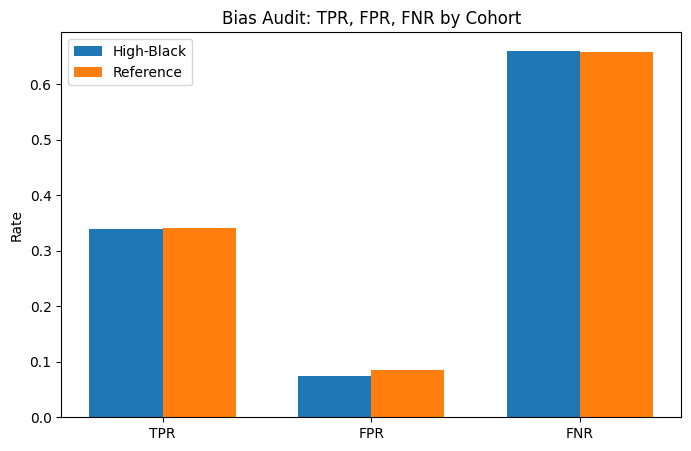

In [16]:
plot_df = pd.DataFrame({
    "Metric": ["TPR", "FPR", "FNR"],
    "High-Black": [hb_metrics["TPR"], hb_metrics["FPR"], hb_metrics["FNR"]],
    "Reference": [ref_metrics["TPR"], ref_metrics["FPR"], ref_metrics["FNR"]]
})

x = np.arange(len(plot_df["Metric"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, plot_df["High-Black"], width, label="High-Black")
plt.bar(x + width/2, plot_df["Reference"], width, label="Reference")
plt.xticks(x, plot_df["Metric"])
plt.ylabel("Rate")
plt.title("Bias Audit: TPR, FPR, FNR by Cohort")
plt.legend()
plt.show()


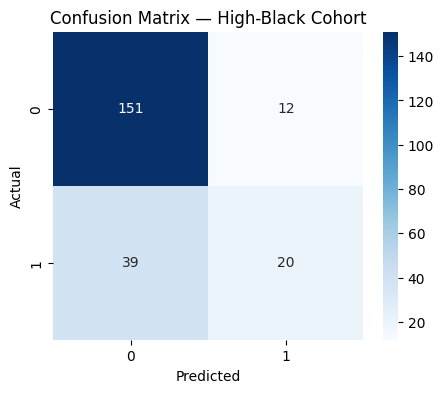

In [17]:
cm_hb = confusion_matrix(high_black["label"], high_black["pred"], labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_hb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — High-Black Cohort")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


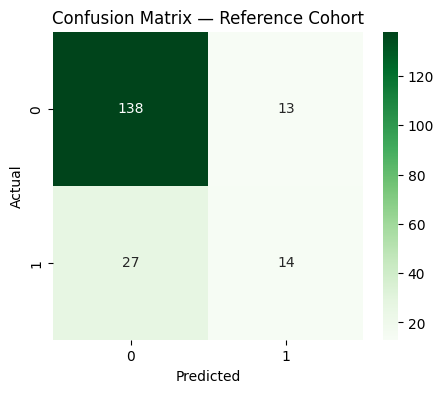

In [18]:
cm_ref = confusion_matrix(reference["label"], reference["pred"], labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_ref, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix — Reference Cohort")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Markdown answer for your notebook

Paste this into a markdown cell and adapt the wording after you see your numbers.

**Interpretation**

The fairness metric with the largest disparity should be identified by comparing TPR, FPR, FNR, statistical parity difference, and equal opportunity difference across the two cohorts. If the high-black cohort has a noticeably higher FPR than the reference cohort, then the model is over-flagging comments associated with Black identity. This wrongly removes or escalates non-toxic comments and creates unequal treatment. If the high-black cohort also has a higher FNR, then the model is missing toxic comments in that cohort as well, showing inconsistent protection. High FPR mainly harms innocent users through false accusations, while high FNR harms targeted users by failing to catch abuse.
